# The RNN never learned the policy: it learned a slow drift toward the wrong certainty

*A standalone study of one finding from the FSC ↔ tinyRNN pipeline.*

## The finding, in one paragraph

On a win-stay/lose-shift (WSLS) task, we fit two minimal models to the same behavior: a
**Finite State Controller** (FSC), a small discrete memory-state controller, and the smallest
**GRU** (tinyRNN) that still explains the data. On ordinary trials they behave the same. Both
reproduce win-stay/lose-shift, and both match the data's action matrix to about 0.002. Underneath,
the two models learned different things. The FSC learned the exact rule; its transition is a lookup
on `(action, observation)`, so "you won, so stay" holds for any amount of evidence. The GRU learned
an approximation that stays correct where the data lives and fails everywhere else. The experiment
in this notebook shows that failure directly.

## The experiment: the off-manifold probe

Take a fitted RNN. Hand it the same trial repeatedly, "you chose arm A, and you won", for `k` steps
in a row. After each step, read its confidence that it will stay, meaning `P(stay)`, the softmax
action-probability at the output. WSLS makes this a flat line: win leads to stay, so after a run of
wins the model should stay with full certainty, `P(stay) = 1.0` at every `k`, forever. A model that
learned the rule can do nothing else.

It doesn't. `P(stay)` sits near 1.0 for the first 28 steps, the longest win-streak that occurs in
the 1000 training sessions, then it drifts down. Feed it enough winning evidence and its confidence
that it should stay falls, sometimes past 0.5 and out the other side. The internal state never
settles where the rule requires. It slides toward a stable fixed point that sits at the wrong
answer. The FSC, asked the same question, answers 1.0 at every `k` and never moves.

## Why this matters

The task is a one-bit rule. We gave the network 1000 sessions. The FSC captured it with two states.
The RNN, at 2, 4, or 8 hidden units, encoded "always stay" as a transient tuned to the evidence
lengths it saw in training. The behavior it produces matches the data; the rule it holds internally
does not. This is the clearest case in the project where fitting the behavior and learning the
policy come apart, and where a continuous recurrent net matches a discrete rule everywhere you can
measure while computing something different underneath.

## Roadmap

- §0 reload the committed fits, reduce everything to plain numpy.
- §1 do the two models read the same on ordinary trials? Deviation-from-data bars.
- §2 the probe: what happens to `P(stay)` under a run of wins? The hero decay curve.
- §3 what does the internal state do while confidence falls? Hidden trajectory and step-size.
- §4 why the network converges to the wrong fixed point. Fixed-point map and table.
- §5 is it just too few units? The per-size grid.
- §6 what held and what drifted across the determinism spectrum. Small-multiple grid and L1.
- §7 what this adds up to.

> **Reproducibility.** This notebook stands alone. It reloads each dataset's committed FSC and GRU
> fits from `fitted_models/<dataset>/`, re-derives one GRU step in pure numpy, and computes every
> figure live. It needs the two upstream repos already cloned on disk (`tinyRNN/`,
> `FSC-inference-MAPSO/`), the same requirement as the main pipeline. It does not rerun Section 0 of
> that pipeline, and it trains nothing.

## 0. Setup: reload the fits, reduce everything to plain numpy

One cell does the heavy lifting. It loads every dataset's committed FSC and GRU fits, pulls the
trained GRU weights into numpy, and precomputes the probe (`P(stay)` vs `k`), the hidden-state
trajectories, and the asymptotic fixed points. Everything after this runs in pure numpy and
matplotlib, so the figures re-run fast and stay easy to read.

Two mechanics come straight from the main pipeline, which documents them:
- **Import switching** (`_use_fsc_path`, `_use_tinyrnn_path`): the two repos ship modules with
  colliding names, so the code swaps `sys.path` and clears stale modules before importing from
  either side.
- **The pure-numpy GRU step** (`gru_step`): torch's `nn.GRU` returns only the hidden state, so we
  re-implement one step to expose the update, reset, and new gates. The main pipeline's §4.3 checks
  it against the library bit for bit.

In [1]:
# --- 0.1 -- imports, path switching, pure-numpy GRU, and the loaders -----------------------
import sys, os, glob, pickle, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Cross-version pandas pickle compat: the det_init model summaries were pickled with a newer
# pandas whose string arrays reduce to a 2-tuple state; teach this build to accept it. No-op
# for same-version pickles, so it is always safe to install. (Same shim as pipeline §0.)
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked
def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], np.ndarray):
        state = (state[0], state[1], {})
    return _NDArrayBacked.__setstate__(self, state)
_pd_str.StringArray.__setstate__ = _compat_string_setstate

REPO         = os.path.abspath(".")
FSC_SRC      = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING   = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path: sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:  sys.path.insert(0, FSC_SRC)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:          sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path: sys.path.insert(0, TINYRNN_ROOT)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

# Datasets, ordered LEAST -> MOST deterministic (the "determinism spectrum" of §6). Each is a
# WSLS variant; committed fits live under fitted_models/<name>/. `original` uses a legacy folder.
DATASETS      = ["rwsls_det_init", "lwsls_det_init", "random_init", "det_init", "original"]
DATASET_FILES = {
    "rwsls_det_init": "datasets/rwsls_actions_observations_det_init.npz",
    "lwsls_det_init": "datasets/lwsls_actions_observations_det_init.npz",
    "random_init":    "datasets/wsls_actions_observations_random_init.npz",
    "det_init":       "datasets/wsls_actions_observations_det_init.npz",
    "original":       "datasets/wsls_actions_observations.npz",
}
EXP_OVERRIDE = {"original": "exp_my_behavior"}   # trained before the exp_<name> convention
H_LIST       = [2, 4, 8]                          # the size sub-study, same as pipeline §4.2
KMAX         = 80                                 # probe length for the decay curves
KGRID        = np.arange(KMAX + 1)                # k = 0 (h=h0) .. KMAX

# ---- one GRU step in numpy, with the three gates exposed (torch nn.GRU equations) ----
def _sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def _softmax(z):
    z = np.asarray(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """Returns (h', {reset r, update z, new n}). h' = (1-z)*n + z*h;  z~1 hold, z~0 overwrite."""
    H  = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r  = _sigmoid(gi[:H]    + gh[:H])
    z  = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n  = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_action_probs(h, P):   # readout: softmax(Linear(h))
    return _softmax(h @ P["lin_W"].T + P["lin_b"])

def extract_gru_params(agent):
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(), "H": net.hidden_dim}

def encode_input(a, y, A, Y):     # one-hot(action) | one-hot(obs), as in pipeline §3.1
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0; return x

# ---- loaders -------------------------------------------------------------------------------
def load_dataset(name):
    raw = np.load(os.path.join(REPO, DATASET_FILES[name]))
    ra, ro = raw["actions"], raw["observations"]
    n_total = ra.shape[0]
    n_use = min(1000, n_total)
    idx = (np.arange(n_total) if n_use == n_total
           else np.random.default_rng(0).choice(n_total, n_use, replace=False))
    ActSpace = np.array(sorted(set(ra[idx].flatten().tolist())))
    ObsSpace = np.array(sorted(set(ro[idx].flatten().tolist())))
    a2i = {v: i for i, v in enumerate(ActSpace)}
    o2i = {v: i for i, v in enumerate(ObsSpace)}
    sessions = [{"actions":      np.array([a2i[a] for a in ra[i]], dtype=int),
                 "observations": np.array([o2i[o] for o in ro[i]], dtype=int)} for i in idx]
    win_idx  = int(np.where(ObsSpace == 1)[0][0]) if 1 in ObsSpace.tolist() else len(ObsSpace) - 1
    lose_idx = 1 - win_idx if len(ObsSpace) == 2 else 0
    return dict(name=name, ActSpace=ActSpace, ObsSpace=ObsSpace, A=len(ActSpace), Y=len(ObsSpace),
                win_idx=win_idx, lose_idx=lose_idx, sessions=sessions)

def load_rnn(name, A, Y, exp_suffix=""):
    """Restore archive->live if needed, then load GRU params at each H (best trainval loss)."""
    _use_tinyrnn_path()
    exp = EXP_OVERRIDE.get(name, f"exp_{name}") + exp_suffix
    live = f"files/saved_model/{exp}"
    arch = os.path.join(REPO, "fitted_models", name, "rnn", exp)
    cwd = os.getcwd(); os.chdir("tinyRNN")
    try:
        if os.path.isdir(arch) and not os.path.isdir(live): shutil.copytree(arch, live)
        if not os.path.isdir(live): return {}
        from agents import Agent
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary, _ = select_final_rnn_perf(exp, return_dim_est=True, verbose=False)
        out = {}
        for H in H_LIST:
            rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
            if len(rows) == 0: continue
            cfg = {"agent_type": "RNN", "rnn_type": "GRU", "input_dim": A + Y, "hidden_dim": H,
                   "output_dim": A, "device": "cpu", "output_h0": True, "trainable_h0": False,
                   "readout_FC": True, "one_hot": False, "seed": 0}
            ag = Agent("RNN", config=cfg); ag.load(str(rows.iloc[0]["model_path"]))
            out[H] = extract_gru_params(ag)
        return out
    finally:
        os.chdir(cwd)

def load_fsc(name):
    _use_fsc_path()
    paths = glob.glob(os.path.join(REPO, f"fitted_models/{name}/fsc/best_fsc_M*.pkl"))
    if not paths: return None
    m = int(paths[0].split("_M")[-1].split(".pkl")[0])
    with open(paths[0], "rb") as f: fsc = pickle.load(f)
    fsc.set_mode("generation")
    return dict(M=m, rho=np.asarray(fsc.get_rho()),
                TMat=np.asarray(fsc.get_TMat()), pol=np.asarray(fsc.get_action_policy()))

print("Setup 0.1 OK: helpers defined.")

Setup 0.1 OK: helpers defined.


In [2]:
# --- 0.2 -- The probe + fixed-point analysis, run once for every dataset -------------------
# For each dataset we cache, per hidden size H and per starting arm a0:
#   * pstay[k]    -- P(stay on a0) after k consecutive (chose a0, won) trials, from h0=0
#   * hidden[k]   -- the hidden state at each k (for §3)
#   * gates[k]    -- update/reset/new gate vectors at each step (cached for reference)
#   * fp_pstay    -- P(stay) at the ASYMPTOTIC fixed point (k -> infinity)
#   * spec_radius -- spectral radius of the map's Jacobian at that fixed point (<1 => stable)
# and the FSC's own P(stay) vs k (a discrete-state belief recursion). Also the empirical +
# model win-stay / lose-shift rates for the on-manifold check in §1.

def rnn_probe(P, a0, y_idx, A, Y, kmax=KMAX):
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"])
    hidden = [h.copy()]; gates = []; pstay = [rnn_action_probs(h, P)[a0]]
    for _ in range(kmax):
        h, g = gru_step(h, x, P); hidden.append(h.copy()); gates.append(g)
        pstay.append(rnn_action_probs(h, P)[a0])
    return dict(pstay=np.array(pstay), hidden=np.array(hidden), gates=gates)

def rnn_fixed_point(P, a0, y_idx, A, Y, n_iter=4000, eps=1e-6):
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"])
    for _ in range(n_iter): h, _ = gru_step(h, x, P)
    J = np.zeros((P["H"], P["H"]))
    for j in range(P["H"]):
        hp = h.copy(); hp[j] += eps
        hpn, _ = gru_step(hp, x, P); J[:, j] = (hpn - h) / eps
    return dict(pstay=float(rnn_action_probs(h, P)[a0]),
                spec_radius=float(np.max(np.abs(np.linalg.eigvals(J)))))

def fsc_probe(FS, a0, y_idx, kmax=KMAX):
    b = FS["rho"].copy(); pstay = [float((b @ FS["pol"])[a0])]
    for _ in range(kmax):
        bn = b @ FS["TMat"][y_idx, :, :, a0]; s = bn.sum()
        b = bn / s if s > 0 else b
        pstay.append(float((b @ FS["pol"])[a0]))
    return np.array(pstay)

def empirical_rates(sessions, win_idx, lose_idx, A):
    """P(stay|win) and P(shift|lose) by straight counting on the behavior."""
    stay_w = shift_l = 0; n_w = n_l = 0
    for s in sessions:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            if o[t-1] == win_idx:
                n_w += 1; stay_w  += (a[t] == a[t-1])
            elif o[t-1] == lose_idx:
                n_l += 1; shift_l += (a[t] != a[t-1])
    return (stay_w / n_w if n_w else np.nan), (shift_l / n_l if n_l else np.nan)

def model_rates(step_probs, sessions, win_idx, lose_idx, A):
    """Teacher-forced replay: average model P(stay|win) and P(shift|lose) over the real
    histories. `step_probs(state)->(probs, next_state)` abstracts FSC vs RNN."""
    stay_w = shift_l = 0.0; n_w = n_l = 0
    for s in sessions:
        a, o = s["actions"], s["observations"]
        st = None
        for t in range(len(a)):
            p, st = step_probs(st, a, o, t)
            if t >= 1:
                if o[t-1] == win_idx:
                    n_w += 1; stay_w  += p[a[t-1]]
                elif o[t-1] == lose_idx:
                    n_l += 1; shift_l += 1 - p[a[t-1]]
    return (stay_w / n_w if n_w else np.nan), (shift_l / n_l if n_l else np.nan)

DATA = {}
for name in DATASETS:
    d = load_dataset(name)
    A, Y, wi, li = d["A"], d["Y"], d["win_idx"], d["lose_idx"]
    d["rnn"] = load_rnn(name, A, Y)
    d["fsc"] = load_fsc(name)

    # win-streak lengths actually present in the data (defines the "in-data" region)
    streaks = []
    for s in d["sessions"]:
        run = 0
        for v in s["observations"]:
            run = run + 1 if v == wi else 0
            streaks.append(run)
    d["streaks"] = np.array(streaks)
    d["max_streak"] = int(d["streaks"].max())

    # off-manifold probe + fixed points, per H per arm
    d["probe"] = {H: {a0: rnn_probe(P, a0, wi, A, Y)          for a0 in range(A)} for H, P in d["rnn"].items()}
    d["fp"]    = {H: {a0: rnn_fixed_point(P, a0, wi, A, Y)     for a0 in range(A)} for H, P in d["rnn"].items()}
    d["fsc_probe"] = ({a0: fsc_probe(d["fsc"], a0, wi) for a0 in range(A)} if d["fsc"] else {})

    # on-manifold rates: data, FSC, each RNN
    d["rate_data"] = empirical_rates(d["sessions"], wi, li, A)
    if d["fsc"]:
        FS = d["fsc"]
        def fsc_step(st, a, o, t, FS=FS, A=A):
            b = FS["rho"].copy() if st is None else st
            p = b @ FS["pol"]
            bn = b @ FS["TMat"][o[t], :, :, a[t]]; s = bn.sum()
            return p, (bn / s if s > 0 else b)
        d["rate_fsc"] = model_rates(fsc_step, d["sessions"], wi, li, A)
    d["rate_rnn"] = {}
    for H, P in d["rnn"].items():
        def rnn_step(st, a, o, t, P=P, A=A, Y=Y):
            h = np.zeros(P["H"]) if st is None else st
            p = rnn_action_probs(h, P)
            hn, _ = gru_step(h, encode_input(a[t], o[t], A, Y), P)
            return p, hn
        d["rate_rnn"][H] = model_rates(rnn_step, d["sessions"], wi, li, A)

    DATA[name] = d
    print(f"{name:>15s}: A={A} Y={Y}  RNN Hs={list(d['rnn'])}  "
          f"FSC M={d['fsc']['M'] if d['fsc'] else '--'}  max win-streak={d['max_streak']}")

_use_fsc_path()
print("\nSetup 0.2 OK: probe and fixed points cached for all datasets.")

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 888.08it/s]

 rwsls_det_init: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=18
Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

...

100%|██████████| 8/8 [00:00<00:00, 1214.95it/s]

       det_init: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=33
Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 1077.60it/s]

       original: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=28

Setup 0.2 OK: probe and fixed points cached for all datasets.


In [3]:
# --- 0.3 -- plot style + a shared color scheme (colorblind-safe categorical slots) ---------
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
C_FSC   = "#111111"   # near-black -- the FSC is the authoritative reference, not a series hue
C_ARM0  = "#2a78d6"   # blue  -- RNN, arm index 0
C_ARM1  = "#eb6834"   # orange-- RNN, arm index 1
C_H     = {2: "#2a78d6", 4: "#eb6834", 8: "#1baf7a"}          # fixed order for the size study
C_ARM   = {0: C_ARM0, 1: C_ARM1}
C_RULE  = "0.35"      # dashed "should be certain" reference
C_TRUE  = "#4a3aa7"   # violet -- the true (possibly non-1) rate on stochastic data
SHADE   = "#8a8a86"

def shade_indata(ax, max_streak, label=True):
    ax.axvspan(0, max_streak, color=SHADE, alpha=0.13, lw=0, zorder=0)
    if label:
        ax.text(max_streak, 0.02, f" longest streak\n in data (k={max_streak})",
                fontsize=7.5, color="0.4", ha="left", va="bottom",
                transform=ax.get_xaxis_transform())

def arm_label(d, a0):
    return f"arm {d['ActSpace'][a0]}"

HERO = "random_init"   # the worked example throughout §2-§4 (this project's primary dataset)
print(f"Style ready. Hero dataset = {HERO!r}.")

Style ready. Hero dataset = 'random_init'.


## 1. On ordinary trials, the two models are indistinguishable

On the trials the data contains, the FSC and the RNN behave the same. Two numbers define WSLS,
`P(stay | previous win)` and `P(shift | previous loss)`. For every dataset, the chart below
compares each model's rates against the real data, plotted as the absolute deviation from the data
on a log scale, so exact matches fall to the floor.

Both models sit within about 0.002 of the real behavior, and the FSC often lands exactly on 0, a
hard 0/1 policy. Behavior on the data's own distribution cannot separate the two models; §2 onward
does. `rwsls_det_init` is the stochastic control: its true rule is genuinely probabilistic, so a
match there means matching a rate near 0.67 rather than hitting 1.0.

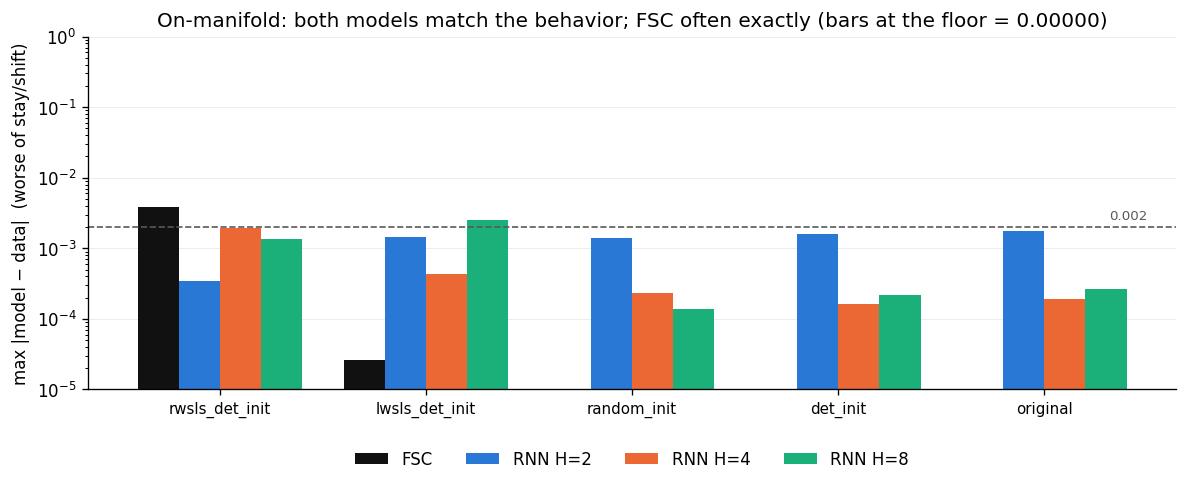

Win-stay / lose-shift rates  (real  |  FSC  |  RNN by H):

  rwsls_det_init
     P(stay|win) : data=0.6653  FSC=0.6691  H2=0.6655  H4=0.6656  H8=0.6645
     P(shift|lose): data=0.2008  FSC=0.2036  H2=0.2011  H4=0.2027  H8=0.2021

  lwsls_det_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9992  H4=0.9997  H8=0.9998
     P(shift|lose): data=0.2004  FSC=0.2004  H2=0.1989  H4=0.2000  H8=0.1978

  random_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9995  H4=0.9998  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9986  H4=0.9998  H8=0.9999

  det_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9995  H4=0.9999  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9984  H4=0.9998  H8=0.9998

  original
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9993  H4=0.9999  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9982  H4=0.9998  H8=0.9997


In [4]:
# --- 1 -- how far each model's win-stay / lose-shift rate sits from the real data ----------
rows = []
for name in DATASETS:
    d = DATA[name]
    sw_d, sl_d = d["rate_data"]
    if d.get("rate_fsc"):
        rows.append((name, "FSC", abs(d["rate_fsc"][0]-sw_d), abs(d["rate_fsc"][1]-sl_d)))
    for H in d["rnn"]:
        rows.append((name, f"RNN H={H}", abs(d["rate_rnn"][H][0]-sw_d), abs(d["rate_rnn"][H][1]-sl_d)))
dev = pd.DataFrame(rows, columns=["dataset", "model", "|Δ P(stay|win)|", "|Δ P(shift|lose)|"])

fig, ax = plt.subplots(figsize=(10, 4.2))
models = ["FSC", "RNN H=2", "RNN H=4", "RNN H=8"]
mcolor = {"FSC": C_FSC, "RNN H=2": C_H[2], "RNN H=4": C_H[4], "RNN H=8": C_H[8]}
x = np.arange(len(DATASETS)); w = 0.2; FLOOR = 1e-5
for i, m in enumerate(models):
    vals = []
    for name in DATASETS:
        sub = dev[(dev["dataset"] == name) & (dev["model"] == m)]
        # worst of the two rates, floored so exact-zero still draws a visible stub
        vals.append(max(sub[["|Δ P(stay|win)|", "|Δ P(shift|lose)|"]].max(axis=1).max(), FLOOR)
                    if len(sub) else FLOOR)
    ax.bar(x + (i - 1.5) * w, vals, w, label=m, color=mcolor[m], edgecolor="none")
ax.set_yscale("log"); ax.set_ylim(FLOOR, 1)
ax.axhline(0.002, color=C_RULE, ls="--", lw=1)
ax.text(len(DATASETS)-0.5, 0.0023, "0.002", fontsize=8, color=C_RULE, va="bottom", ha="right")
ax.set_xticks(x); ax.set_xticklabels(DATASETS, fontsize=9)
ax.set_ylabel("max |model − data|  (worse of stay/shift)")
ax.set_title("On-manifold: both models match the behavior; FSC often exactly (bars at the floor = 0.00000)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13))
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("Win-stay / lose-shift rates  (real  |  FSC  |  RNN by H):")
for name in DATASETS:
    d = DATA[name]
    print(f"\n  {name}")
    print(f"     P(stay|win) : data={d['rate_data'][0]:.4f}"
          + (f"  FSC={d['rate_fsc'][0]:.4f}" if d.get('rate_fsc') else "")
          + "".join(f"  H{H}={d['rate_rnn'][H][0]:.4f}" for H in d["rnn"]))
    print(f"     P(shift|lose): data={d['rate_data'][1]:.4f}"
          + (f"  FSC={d['rate_fsc'][1]:.4f}" if d.get('rate_fsc') else "")
          + "".join(f"  H{H}={d['rate_rnn'][H][1]:.4f}" for H in d["rnn"]))

## 2. The probe: hand it a run of wins and watch its confidence fall

Take the hero dataset (`random_init`) and its smallest RNN, `H=2`. Drive it from a blank state with
the same trial repeated, chose arm A and won, and after each of `k` steps read `P(stay on A)`. WSLS
makes this a flat line at 1.0: you keep winning, you keep staying, with growing certainty. The FSC
(black) holds that line. The RNN slides off it.

The shaded band marks the longest win-streak anywhere in the 1000 training sessions. Inside the
band the RNN holds near 1.0, the region where training pinned it down. Past the band its confidence
slides, and the two arms diverge: one stays at 1.0, the other collapses. Section 5 shows the
collapsing arm is a training coin-toss rather than a property of the task.

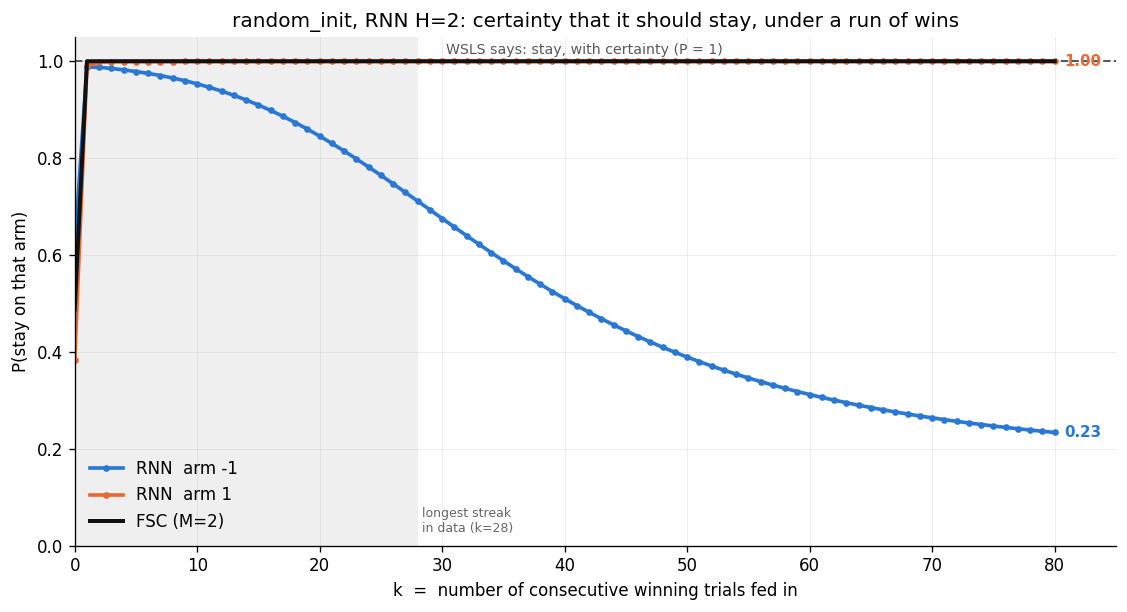

P(stay) at k=1 vs k=80   (should be 1.000 at both, per WSLS):
    arm -1:  0.988  ->  0.234   <-- collapses
     arm 1:  0.990  ->  1.000   (holds)
   FSC    :  1.000  ->  1.000   (flat, a lookup table)


In [5]:
# --- 2 -- the hero decay curve: P(stay) vs k on random_init, H=2, both arms + FSC ----------
d = DATA[HERO]; H = 2; A = d["A"]
fig, ax = plt.subplots(figsize=(9.5, 5.2))
shade_indata(ax, d["max_streak"])
ax.axhline(1.0, color=C_RULE, ls="--", lw=1.2)
ax.text(KMAX * 0.52, 1.008, "WSLS says: stay, with certainty (P = 1)", fontsize=8.5,
        color=C_RULE, ha="center", va="bottom")

for a0 in range(A):
    ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_ARM[a0], lw=2.2,
            marker="o", ms=3, label=f"RNN  {arm_label(d, a0)}")
    ax.annotate(f"{d['probe'][H][a0]['pstay'][-1]:.2f}", (KMAX, d["probe"][H][a0]["pstay"][-1]),
                xytext=(6, 0), textcoords="offset points", color=C_ARM[a0], fontsize=9,
                va="center", fontweight="bold")
if d["fsc_probe"]:
    ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=2.4, label=f"FSC (M={d['fsc']['M']})")

ax.set_xlim(0, KMAX + 5); ax.set_ylim(0, 1.05)
ax.set_xlabel("k  =  number of consecutive winning trials fed in")
ax.set_ylabel("P(stay on that arm)")
ax.set_title(f"{HERO}, RNN H={H}: certainty that it should stay, under a run of wins")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

print(f"P(stay) at k=1 vs k={KMAX}   (should be 1.000 at both, per WSLS):")
for a0 in range(A):
    p = d["probe"][H][a0]["pstay"]
    print(f"   {arm_label(d, a0):>7s}:  {p[1]:.3f}  ->  {p[KMAX]:.3f}"
          + ("   <-- collapses" if p[KMAX] < 0.9 else "   (holds)"))
if d["fsc_probe"]:
    print(f"   FSC    :  {d['fsc_probe'][0][1]:.3f}  ->  {d['fsc_probe'][0][KMAX]:.3f}   (flat, a lookup table)")

## 3. What the internal state does while confidence falls

`P(stay)` reads out the hidden state `h`, so look at `h` directly. The left panel traces each
hidden unit over `k` for both arms. The right panel carries the result: the step size, the norm of
`h(k+1) - h(k)`, meaning how far the state still moves each time it receives the same input.

A model that learned "always stay" would drive `h` to a fixed point, a state the repeated input
leaves unchanged, so the step size would crash to zero and stay there. The holding arm does that;
its curve drops off the bottom of the log axis. The collapsing arm keeps moving for tens of steps
and drags the readout down the whole way. The FSC's belief (dotted) reaches its fixed point after
one step; a single lookup finishes it.

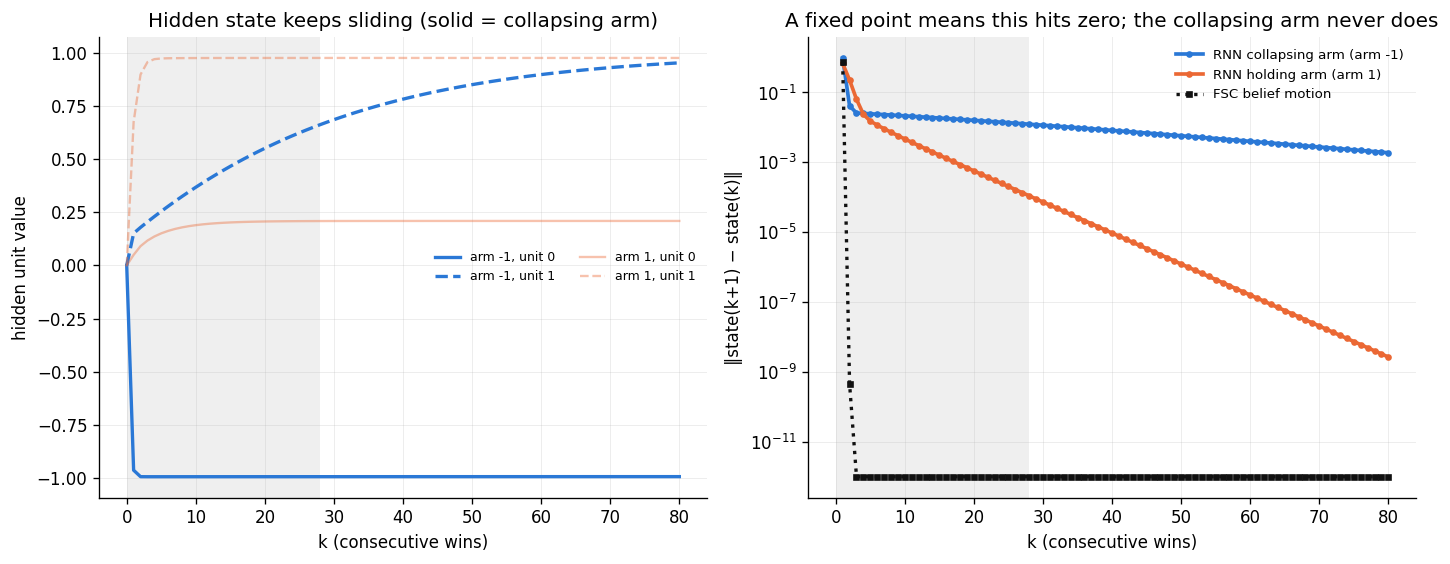

Holding arm  = arm 1  (fixed-point P(stay) = 1.000)
Collapsing arm = arm -1  (fixed-point P(stay) = 0.178)


In [6]:
# --- 3 -- hidden-state trajectory (left) and per-step motion (right) -----------------------
d = DATA[HERO]; H = 2; A = d["A"]
# identify which arm holds and which collapses, from the cached fixed points
fp = d["fp"][H]
hold_arm  = max(range(A), key=lambda a: fp[a]["pstay"])
drift_arm = min(range(A), key=lambda a: fp[a]["pstay"])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.8))

# left: hidden components vs k, collapsing arm solid, holding arm faded
for a0, style in [(drift_arm, dict(lw=2.0, alpha=1.0)), (hold_arm, dict(lw=1.4, alpha=0.4))]:
    hid = d["probe"][H][a0]["hidden"]
    for u in range(H):
        axL.plot(KGRID, hid[:, u], color=C_ARM[a0], ls=["-", "--"][u % 2],
                 label=(f"{arm_label(d, a0)}, unit {u}"), **style)
shade_indata(axL, d["max_streak"], label=False)
axL.set_xlabel("k (consecutive wins)"); axL.set_ylabel("hidden unit value")
axL.set_title("Hidden state keeps sliding (solid = collapsing arm)")
axL.legend(fontsize=7.5, ncol=2, loc="best")

# right: step size ||dh|| vs k, log scale
for a0, lbl in [(drift_arm, "collapsing arm"), (hold_arm, "holding arm")]:
    hid = d["probe"][H][a0]["hidden"]
    dh = np.linalg.norm(np.diff(hid, axis=0), axis=1)
    axR.semilogy(KGRID[1:], np.clip(dh, 1e-12, None), color=C_ARM[a0], lw=2.2,
                 marker="o", ms=3, label=f"RNN {lbl} ({arm_label(d, a0)})")
if d["fsc_probe"]:
    # FSC belief motion: change in belief vector per step
    b = d["fsc"]["rho"].copy(); moves = []
    for _ in range(KMAX):
        bn = b @ d["fsc"]["TMat"][d["win_idx"], :, :, drift_arm]; s = bn.sum()
        bn = bn / s if s > 0 else b; moves.append(np.linalg.norm(bn - b)); b = bn
    axR.semilogy(KGRID[1:], np.clip(moves, 1e-12, None), color=C_FSC, lw=2.0, ls=":",
                 marker="s", ms=3, label="FSC belief motion")
shade_indata(axR, d["max_streak"], label=False)
axR.set_xlabel("k (consecutive wins)"); axR.set_ylabel("‖state(k+1) − state(k)‖")
axR.set_title("A fixed point means this hits zero; the collapsing arm never does")
axR.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()

print(f"Holding arm  = {arm_label(d, hold_arm)}  (fixed-point P(stay) = {fp[hold_arm]['pstay']:.3f})")
print(f"Collapsing arm = {arm_label(d, drift_arm)}  (fixed-point P(stay) = {fp[drift_arm]['pstay']:.3f})")

## 4. Why the network converges to the wrong fixed point

The slide in §3 is a contraction. Under the constant input the GRU map `h ↦ h'` has one stable
fixed point `h*`, and the state is pulled into it. Two facts make that fixed point the cause, and
both hold across every dataset, size, and arm.

First, it converges. Iterate the same "you won" input to convergence and linearize there: the
Jacobian's spectral radius stays below 1 everywhere. The network settles rather than oscillating or
diverging. A short algebraic note on where it settles: at a fixed point, `h' = (1-z)·n + z·h` forces
`h* = n*`, the candidate state. The input-driven proposal sets the resting state, and nothing
latches the readout at 1.0. The resting readout equals `softmax(Linear(n*))`, whatever that comes
out to.

Second, on the collapsing arms that resting readout is the wrong certainty, with `P(stay)` fixed
points near 0.1 to 0.2 in place of 1.0. The spectral radius sits just under 1 (about 0.96 to 0.99),
so the pull is slow. Across the win-streaks of at most 28 steps the data contains, the readout
barely moves, which is why training never charged the network for it. Past those streak lengths the
same slow contraction continues, all the way to the wrong answer.

The RNN converged on a different rule: after a long run of wins, drift toward unsure or flip
outright. The chart below places every configuration's fixed point on the `P(stay)` axis, and the
table gives the numbers. The FSC can land only on 1.0, since its winning memory-state maps to
itself, a true fixed point at the exact policy value.

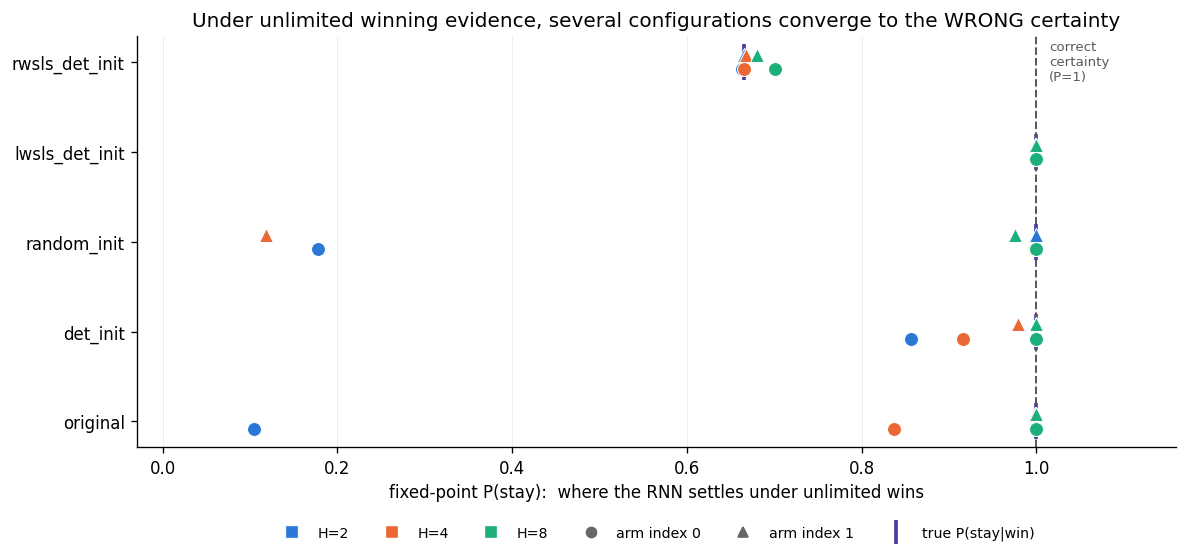

In [7]:
# --- 4a -- where UNLIMITED winning evidence actually takes each RNN (the fixed points) ------
# One row per dataset; each point is one (H, arm) configuration placed at its fixed-point P(stay).
# A model that learned WSLS would put every point on the "correct certainty" line. Marker shape =
# arm, color = hidden size. The violet tick is the dataset's TRUE P(stay|win) (=1.0 when the rule
# is deterministic, ~0.67 on the stochastic control) -- the value a correct model should converge to.
fig, ax = plt.subplots(figsize=(10, 4.8))
ymap = {name: i for i, name in enumerate(reversed(DATASETS))}   # most-deterministic on top
marker = {0: "o", 1: "^"}
for name in DATASETS:
    d = DATA[name]; y = ymap[name]
    for H in d["rnn"]:
        for a0 in range(d["A"]):
            fpv = d["fp"][H][a0]["pstay"]
            ax.scatter(fpv, y + (a0 - 0.5) * 0.16, s=70, color=C_H[H], marker=marker[a0],
                       edgecolor="white", linewidth=0.6, zorder=3)
    ax.plot([d["rate_data"][0]], [y], marker="|", ms=22, color=C_TRUE, mew=2.2, zorder=2)
ax.axvline(1.0, color=C_RULE, ls="--", lw=1.2)
ax.text(1.015, len(DATASETS) - 1, "correct\ncertainty\n(P=1)",
        fontsize=8, color=C_RULE, ha="left", va="center")
ax.set_yticks(list(ymap.values())); ax.set_yticklabels(list(ymap.keys()))
ax.set_xlim(-0.03, 1.16); ax.set_xlabel("fixed-point P(stay):  where the RNN settles under unlimited wins")
ax.set_title("Under unlimited winning evidence, several configurations converge to the WRONG certainty")
# legends: color=H, shape=arm, tick=true rate
from matplotlib.lines import Line2D
h_handles = [Line2D([], [], marker="s", ls="", color=C_H[H], label=f"H={H}") for H in H_LIST]
a_handles = [Line2D([], [], marker=marker[a], ls="", color="0.4", label=f"arm index {a}") for a in (0, 1)]
t_handle  = [Line2D([], [], marker="|", ls="", color=C_TRUE, mew=2.2, ms=14, label="true P(stay|win)")]
ax.legend(handles=h_handles + a_handles + t_handle, ncol=6, loc="upper center",
          bbox_to_anchor=(0.5, -0.16), fontsize=8.5)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [8]:
# --- 4b -- the fixed-point table: where unlimited winning evidence actually takes each RNN --
rows = []
for name in DATASETS:
    d = DATA[name]
    for H in d["rnn"]:
        for a0 in range(d["A"]):
            fp = d["fp"][H][a0]
            rows.append({
                "dataset": name, "H": H, "arm": str(d["ActSpace"][a0]),
                "P(stay) k=1":   round(float(d["probe"][H][a0]["pstay"][1]), 3),
                "P(stay) k=80":  round(float(d["probe"][H][a0]["pstay"][KMAX]), 3),
                "P(stay) fixed-pt": round(fp["pstay"], 3),
                "spectral radius":  round(fp["spec_radius"], 3),
                "verdict": ("correctly certain" if fp["pstay"] > 0.95 else
                            "drifts to WRONG certainty" if fp["pstay"] < 0.55 else
                            "partial drift"),
            })
fp_table = pd.DataFrame(rows)
# show the hero + the clearest failures first
print("Fixed-point analysis: the state each RNN settles into under UNLIMITED winning evidence.")
print("(WSLS requires P(stay) fixed-point = 1.000 on every deterministic dataset.)\n")
fp_table

Fixed-point analysis: the state each RNN settles into under UNLIMITED winning evidence.
(WSLS requires P(stay) fixed-point = 1.000 on every deterministic dataset.)



,dataset,H,arm,P(stay) k=1,P(stay) k=80,P(stay) fixed-pt,spectral radius,verdict
0,rwsls_det_init,2,-1,0.671,0.663,0.663,0.070,partial drift
1,rwsls_det_init,2,1,0.674,0.666,0.666,0.053,partial drift
2,rwsls_det_init,4,-1,0.692,0.665,0.665,0.217,partial drift
3,rwsls_det_init,4,1,0.574,0.668,0.668,0.226,partial drift
4,rwsls_det_init,8,-1,0.657,0.701,0.701,0.840,partial drift
5,rwsls_det_init,8,1,0.643,0.680,0.680,0.569,partial drift
6,lwsls_det_init,2,-1,1.000,1.000,1.000,0.303,correctly certain
7,lwsls_det_init,2,1,0.997,0.999,0.999,0.082,correctly certain
8,lwsls_det_init,4,-1,0.998,1.000,1.000,0.554,correctly certain
9,lwsls_det_init,4,1,0.999,0.999,0.999,0.620,correctly certain


## 5. Adding hidden units does not fix the drift

The natural objection says `H=2` is too small. The probe rules that out. Below it runs on
`random_init` at `H=2, 4, 8`. Every size reproduces WSLS on the data manifold (§1), and every size
breaks on a different arm: `H=2` collapses one arm, `H=4` the other, with the choice set by random
initialization. Extra units relocate the crack to a different arm and leave the drift in place. The
main pipeline's participation-ratio analysis reaches the same conclusion from another angle: these
RNNs use only about 1.7 to 2.8 effective dimensions regardless of how many units they hold.

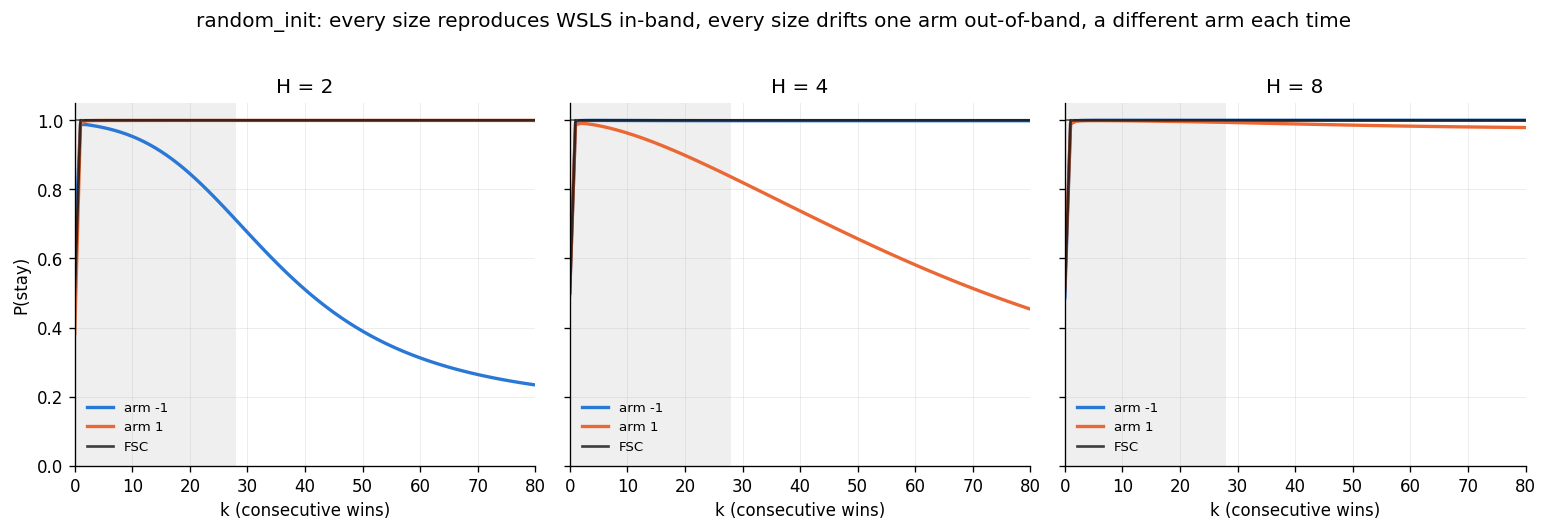

Fixed-point P(stay) per size and arm (which arm stays certain flips with size):
   H=2: arm -1=0.178   arm 1=1.000
   H=4: arm -1=0.999   arm 1=0.119
   H=8: arm -1=1.000   arm 1=0.975


In [9]:
# --- 5 -- same probe, three sizes: each holds one arm and drifts the other -----------------
d = DATA[HERO]; A = d["A"]
fig, axes = plt.subplots(1, len(H_LIST), figsize=(13, 4.3), sharey=True)
for ax, H in zip(axes, H_LIST):
    if H not in d["probe"]:
        ax.set_visible(False); continue
    shade_indata(ax, d["max_streak"], label=False)
    ax.axhline(1.0, color=C_RULE, ls="--", lw=1)
    for a0 in range(A):
        ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_ARM[a0], lw=2.0,
                label=arm_label(d, a0))
    if d["fsc_probe"]:
        ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=1.6, alpha=0.8, label="FSC")
    ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
    ax.set_title(f"H = {H}"); ax.set_xlabel("k (consecutive wins)")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("P(stay)")
fig.suptitle(f"{HERO}: every size reproduces WSLS in-band, every size drifts one arm out-of-band, "
             "a different arm each time", y=1.02)
plt.tight_layout(); plt.show()

print("Fixed-point P(stay) per size and arm (which arm stays certain flips with size):")
for H in d["rnn"]:
    print(f"   H={H}: " + "   ".join(f"{arm_label(d, a0)}={d['fp'][H][a0]['pstay']:.3f}" for a0 in range(A)))

## 6. The whole spectrum: what held and what drifted

The finding varies across datasets, which is worth showing plainly. The probe below runs on all
five, ordered from the least deterministic rule (top-left) to the most (bottom). Each panel draws
the worst-drifting arm at each size, the FSC, and a dashed line at the true `P(stay|win)` the rule
implies.

- `rwsls_det_init` is the honest control. Its rule is genuinely stochastic, `P(stay|win)` near 0.67.
  The RNN's curve flattening below 1.0 is the correct behavior here, and it reaches a real fixed
  point at that value. A stable fixed point is fine when the true rule is stochastic. The failure
  appears on the deterministic datasets, where the fixed point lands at the wrong value.
- `lwsls_det_init` has a deterministic win side and holds well.
- `random_init`, `det_init`, and `original` all have a fully deterministic `P(stay|win)=1.0`, and
  all show at least one arm or size drifting off it once the input leaves the data.

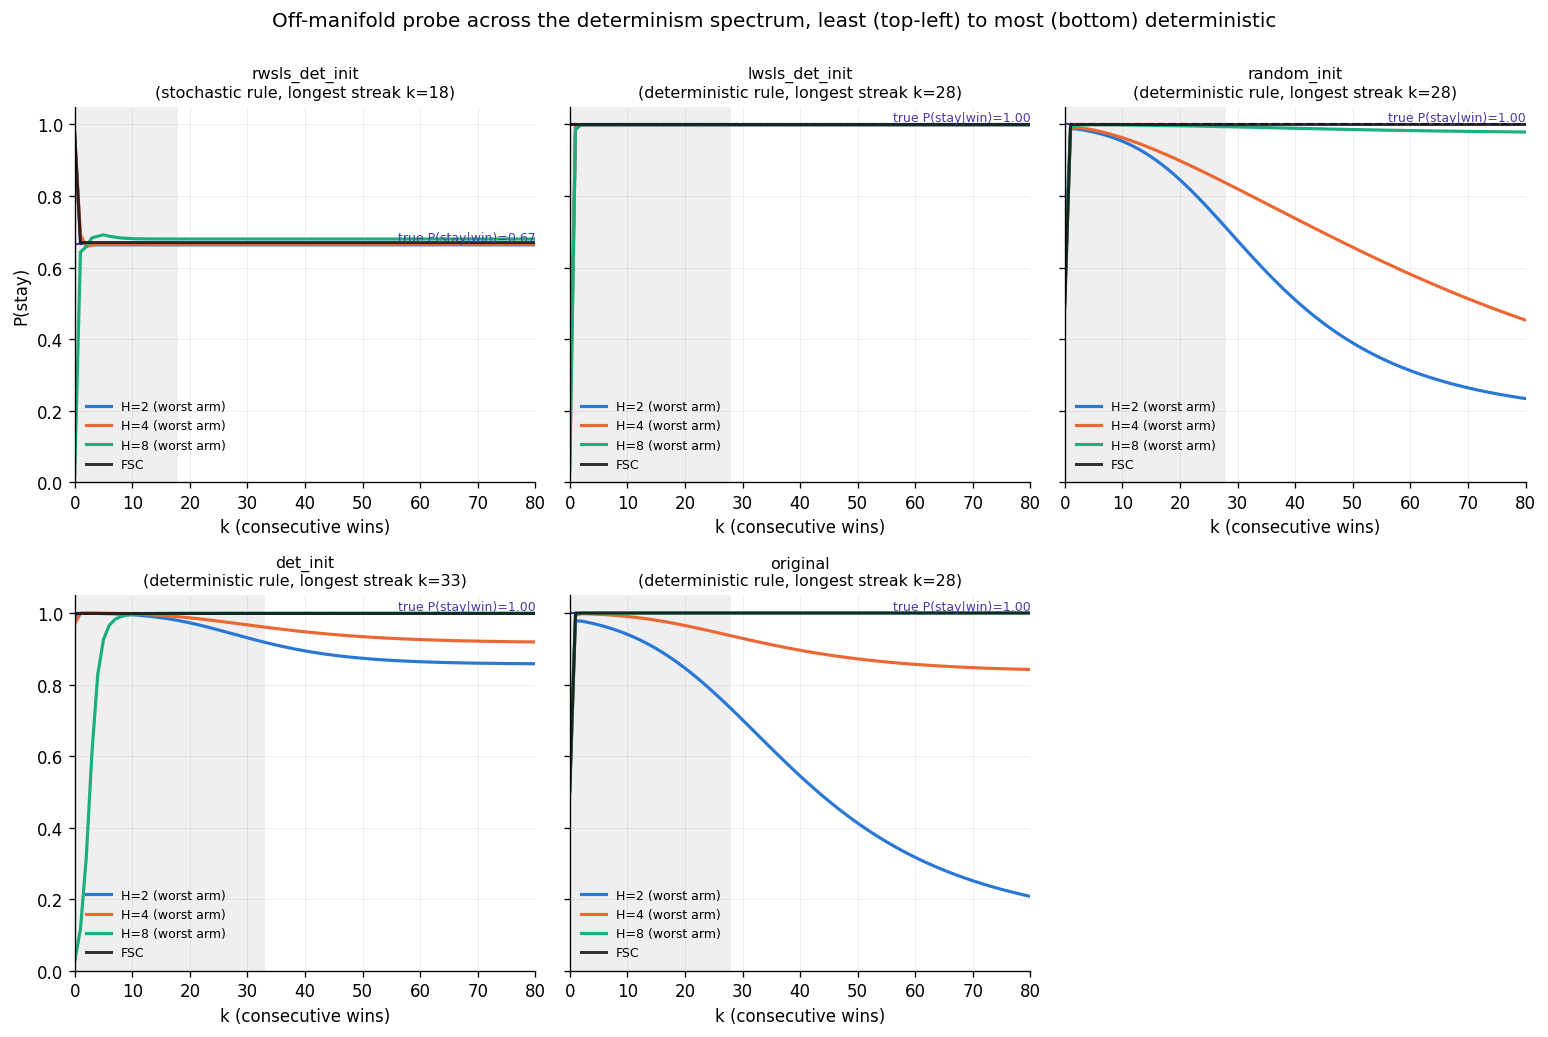

In [10]:
# --- 6 -- small-multiple grid: the probe across the determinism spectrum --------------------
ncol = 3; nrow = int(np.ceil(len(DATASETS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.3 * nrow), sharey=True)
axes = axes.ravel()
for ax, name in zip(axes, DATASETS):
    d = DATA[name]; A = d["A"]
    shade_indata(ax, d["max_streak"], label=False)
    true_sw = d["rate_data"][0]
    ax.axhline(true_sw, color=C_TRUE, ls="--", lw=1.3)
    ax.text(KMAX, true_sw, f" true P(stay|win)={true_sw:.2f}", fontsize=7.5,
            color=C_TRUE, ha="right", va="bottom")
    for H in d["rnn"]:
        # worst-drifting arm for this size = lowest fixed-point P(stay)
        a0 = min(range(A), key=lambda a: d["fp"][H][a]["pstay"])
        ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_H[H], lw=1.9,
                label=f"H={H} (worst arm)")
    if d["fsc_probe"]:
        ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=1.8, alpha=0.85, label="FSC")
    ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
    det = "stochastic rule" if true_sw < 0.95 else "deterministic rule"
    ax.set_title(f"{name}\n({det}, longest streak k={d['max_streak']})", fontsize=9.5)
    ax.set_xlabel("k (consecutive wins)"); ax.legend(fontsize=7.5, loc="lower left")
for ax in axes[len(DATASETS):]:
    ax.set_visible(False)
axes[0].set_ylabel("P(stay)")
fig.suptitle("Off-manifold probe across the determinism spectrum, least (top-left) to most (bottom) deterministic",
             y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

### 6b. More regularization makes it worse

One more knob, because the result runs against intuition. Two datasets ship a second committed RNN
fit trained with a heavier L1 penalty on the recurrent weights (`1e-3` against the `1e-5`
baseline): `random_init` from this project, and `det_init` from the merged det-init branch. Heavier
weight shrinkage would be expected to buy a simpler, steadier rule. It does the opposite.

A note on reading this fairly: the two penalties are separately trained networks, and each breaks
symmetry on its own arm (§5), so comparing a fixed arm index across them says nothing. The fair
comparison uses each network's own worst arm and asks how far that arm falls by `k=80`. On that
measure the heavier penalty drifts further in five of the six dataset/size cells. `random_init`
worsens at every size (`H=2` 0.23 to 0.02, `H=4` 0.45 to 0.33, `H=8` 0.98 to 0.52), and `det_init`
worsens at `H=2` (0.86 to 0.12) and `H=8` (1.00 to 0.28); `det_init` `H=4` is the lone cell that
improves (0.92 to 0.99). Heavier L1 produces more off-manifold drift as the rule.

This sits against the det_init story in the main pipeline's §13, and the two fit together. There,
heavier L1 helps the in-distribution picture: it makes the automatic size-selector decisive
(p=0.029 to p=0.004) and pulls effective dimensionality back into the pack (participation ratio
2.85 to 1.82). Off the data manifold it does the reverse and deepens the drift. Regularization buys
in-distribution tidiness at the cost of off-manifold certainty. The main pipeline's §9.3b shows the
same drift effect on `random_init`.

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 1071.68it/s]

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

...

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 2202.17it/s]

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 2267.65it/s]

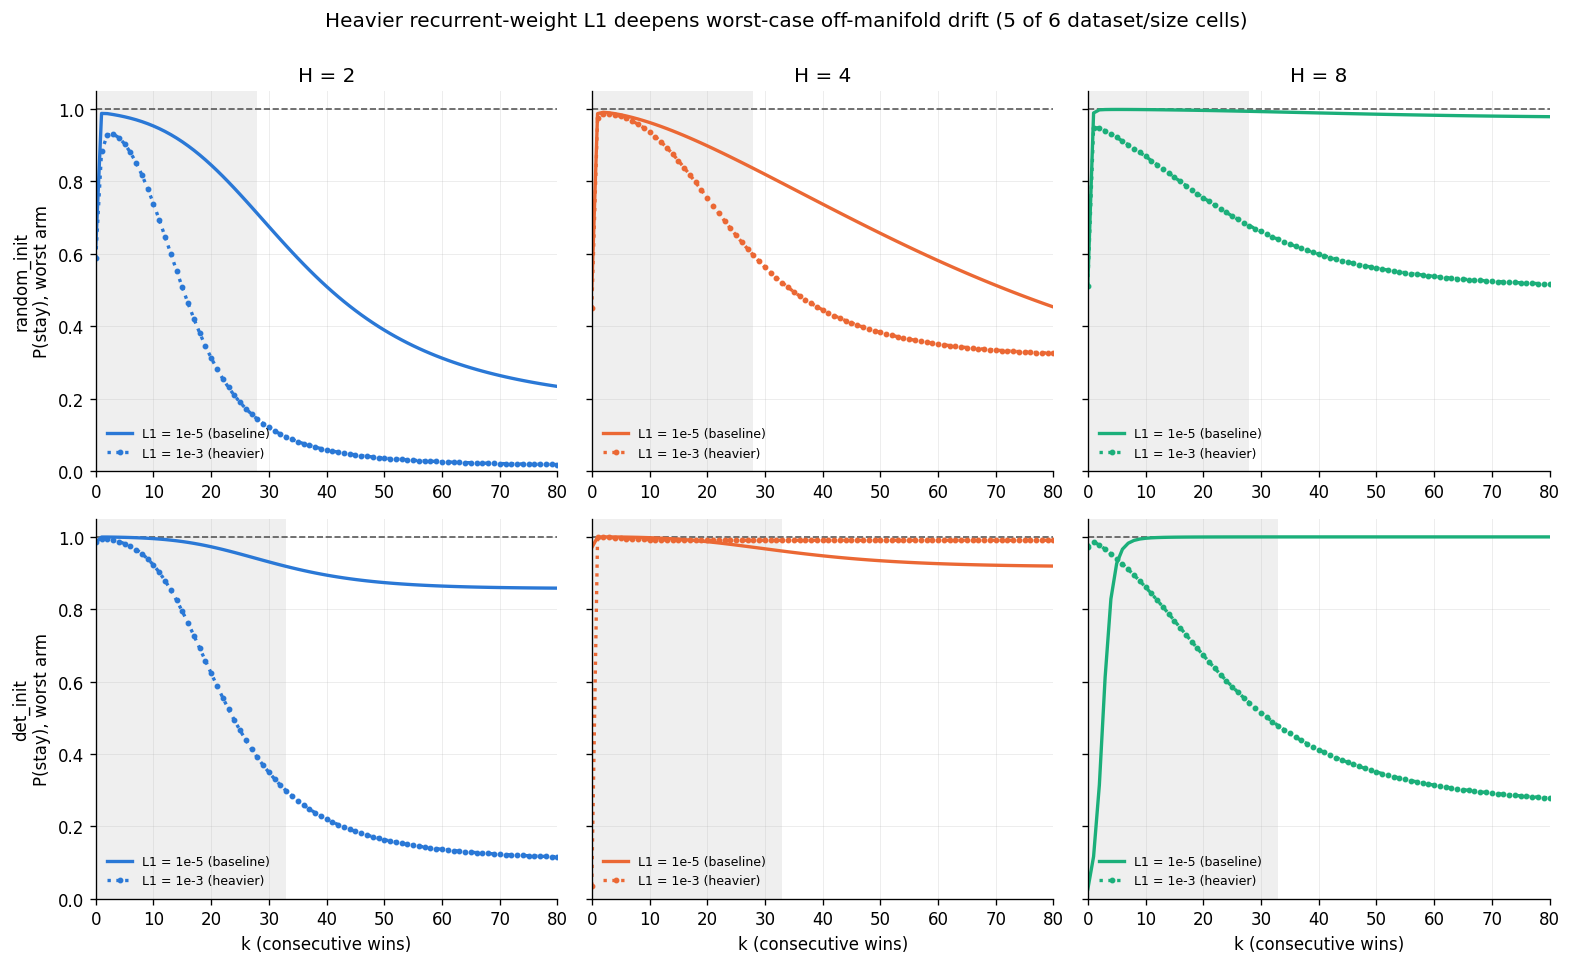

Worst-arm P(stay) at k=80  (lower = drifts further; * = heavier L1 drifts further):
  random_init
     H=2:  L1=1e-5 -> 0.234   L1=1e-3 -> 0.018   *
     H=4:  L1=1e-5 -> 0.453   L1=1e-3 -> 0.325   *
     H=8:  L1=1e-5 -> 0.979   L1=1e-3 -> 0.517   *
  det_init
     H=2:  L1=1e-5 -> 0.858   L1=1e-3 -> 0.116   *
     H=4:  L1=1e-5 -> 0.919   L1=1e-3 -> 0.990    
     H=8:  L1=1e-5 -> 1.000   L1=1e-3 -> 0.278   *


In [11]:
# --- 6b -- the same probe under a heavier L1 penalty, on every dataset that has an L1 sweep -
# Two datasets ship a committed L1=1e-3 sweep beside the 1e-5 baseline: random_init (this
# project) and det_init (added by the merged det-init branch). Each network breaks symmetry on
# its own arm (§5), so we compare each network's OWN worst arm: how far the more-drifting arm
# falls by k=KMAX. Rows are datasets, columns are hidden sizes.
L1_DATASETS = [name for name in ("random_init", "det_init")
               if load_rnn(name, DATA[name]["A"], DATA[name]["Y"], exp_suffix="_l1-0.001")]
_use_fsc_path()

def _worst_arm(probe_dict, H, A):        # lowest P(stay) at k=KMAX
    return min(range(A), key=lambda a: probe_dict[H][a]["pstay"][KMAX])

l1_probe = {}     # {dataset: {H: {arm: probe}}}
for name in L1_DATASETS:
    dd = DATA[name]
    rnn_l1 = load_rnn(name, dd["A"], dd["Y"], exp_suffix="_l1-0.001"); _use_fsc_path()
    l1_probe[name] = {H: {a0: rnn_probe(P, a0, dd["win_idx"], dd["A"], dd["Y"])
                          for a0 in range(dd["A"])} for H, P in rnn_l1.items()}

fig, axes = plt.subplots(len(L1_DATASETS), len(H_LIST),
                         figsize=(4.4 * len(H_LIST), 4.0 * len(L1_DATASETS)), sharey=True, squeeze=False)
worse = total = 0
for r, name in enumerate(L1_DATASETS):
    dd = DATA[name]; A = dd["A"]
    for c, H in enumerate(H_LIST):
        ax = axes[r, c]
        if H not in dd["probe"] or H not in l1_probe[name]:
            ax.set_visible(False); continue
        shade_indata(ax, dd["max_streak"], label=False)
        ax.axhline(1.0, color=C_RULE, ls="--", lw=1)
        ab = _worst_arm(dd["probe"], H, A)
        al = _worst_arm(l1_probe[name], H, A)
        base_end, l1_end = dd["probe"][H][ab]["pstay"][KMAX], l1_probe[name][H][al]["pstay"][KMAX]
        total += 1; worse += (l1_end < base_end)
        ax.plot(KGRID, dd["probe"][H][ab]["pstay"], color=C_H[H], lw=2.0, label="L1 = 1e-5 (baseline)")
        ax.plot(KGRID, l1_probe[name][H][al]["pstay"], color=C_H[H], lw=2.0, ls=":", marker="o",
                ms=2.5, label="L1 = 1e-3 (heavier)")
        ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
        if r == 0: ax.set_title(f"H = {H}")
        if r == len(L1_DATASETS) - 1: ax.set_xlabel("k (consecutive wins)")
        ax.legend(fontsize=7.5, loc="lower left")
    axes[r, 0].set_ylabel(f"{name}\nP(stay), worst arm")
fig.suptitle("Heavier recurrent-weight L1 deepens worst-case off-manifold drift "
             f"({worse} of {total} dataset/size cells)", y=1.0)
plt.tight_layout(); plt.show()

print(f"Worst-arm P(stay) at k={KMAX}  (lower = drifts further; * = heavier L1 drifts further):")
for name in L1_DATASETS:
    dd = DATA[name]; A = dd["A"]
    print(f"  {name}")
    for H in H_LIST:
        if H not in dd["probe"] or H not in l1_probe[name]:
            continue
        b = dd["probe"][H][_worst_arm(dd["probe"], H, A)]["pstay"][KMAX]
        l = l1_probe[name][H][_worst_arm(l1_probe[name], H, A)]["pstay"][KMAX]
        print(f"     H={H}:  L1=1e-5 -> {b:.3f}   L1=1e-3 -> {l:.3f}   {'*' if l < b else ' '}")

## 7. What this adds up to

1. **Matching behavior does not certify the policy.** On every dataset, across the trials that
occur, the FSC and the RNN land within about 0.002 of the real win-stay/lose-shift rates (§1). On
behavior alone they read as interchangeable, and that reading is wrong.

2. **The RNN never learned "always stay."** Fed a run of wins longer than the streaks in the data,
its confidence that it should stay falls (§2). The FSC answers 1.0 forever, because its transition
is a lookup on `(action, observation)` and has no off-manifold behavior to get wrong.

3. **It learned a slow transient toward the wrong fixed point.** On the failing arm the hidden state
keeps moving where a learned latch would have gone quiet (§3). Under unlimited winning evidence the
network converges stably, Jacobian spectral radius below 1, onto a fixed point whose readout is the
wrong certainty, often near-random or flipped (§4). The eigenvalues sit just under 1, so the
approach is slow enough to hide inside the streaks of at most 28 steps the data contains, which is
why training never penalized it.

4. **Capacity is not the limiter.** Every size reproduces WSLS in-band, and every size drifts one
arm out-of-band, a different arm each time depending on initialization (§5). Extra units relocate
the crack. Heavier L1 regularization deepens it (§6b).

5. **The one clean case is the one that needs no certainty.** On the stochastic `rwsls_det_init`,
the true rule is `P(stay|win)` near 0.67, and the RNN's fixed point lands there (§6). The failure is
specific: the network cannot hold an extreme 0 or 1 certainty off the data manifold, even for a
trivial rule seen across 1000 sessions.

**For the project.** A discrete controller and a small GRU can be behaviorally identical while
differing in kind. The FSC represents the rule; the RNN approximates it on the support of the data.
Any claim that "the RNN learned the strategy" has to be tested off the data manifold, since
on-distribution behavior cannot separate the two. This is the cleanest demonstration of that gap in
the pipeline, and the probe is the tool that makes it visible.

Scope: all five datasets are one-bit WSLS variants. That makes them the right setting to validate
the diagnostic, since we know the answer and the probe recovers it. It makes them the wrong setting
for claims about when RNN capacity pays off. The next test is a task with real multi-step memory.